# Train-Free Segmentation in MRI with Cubical Persistent Homology
## Glioblastoma segmentation

Anton François & Raphaël Tinarrage

See the repo at https://github.com/antonfrancois/gliomaSegmentation_TDA and article at https://arxiv.org/abs/2401.01160

In [1]:
import parseBrats as pB
from segmentations import segment_brain
from utils import get_multiple_dice, plot_images_and_segmentation, plot_comparison_full_segmentations

In [2]:
#Silence skimage warning.
import warnings
warnings.filterwarnings(
    "ignore",
    message=r"Possible precision loss converting image of type .* to uint8 as required by rank filters",
    category=UserWarning,
    module=r"skimage\.filters\.rank\..*",
)

## Open an image
One can select one or more files by putting them into `brats_list`, or set it to None to choose randomly from the whole data set.

In [3]:
# Open Brats folder.
brats_list = ["BraTS-GLI-01304-000", "BraTS-GLI-01339-000", "BraTS-GLI-01401-000", "BraTS-GLI-00780-000",
    "BraTS-GLI-00491-001", "BraTS-GLI-01368-000", "BraTS-GLI-00078-000", "BraTS-GLI-00183-000", "BraTS-GLI-01122-000",
    "BraTS-GLI-01121-000", ]
pb = pB.parse_brats(brats_list=brats_list, brats_folder="2025", modality="flair", get_template=False)

In [4]:
# Open a specific image.
img_idx = 4
img_flair, seg_gt = pb(img_idx, to_torch=False, modality="flair", normalize=True)
img_t1ce, _ = pb(img_idx, to_torch=False, modality="t1ce")
print("Image name:", pb.brats_list[img_idx])

Image name: BraTS-GLI-00491-001


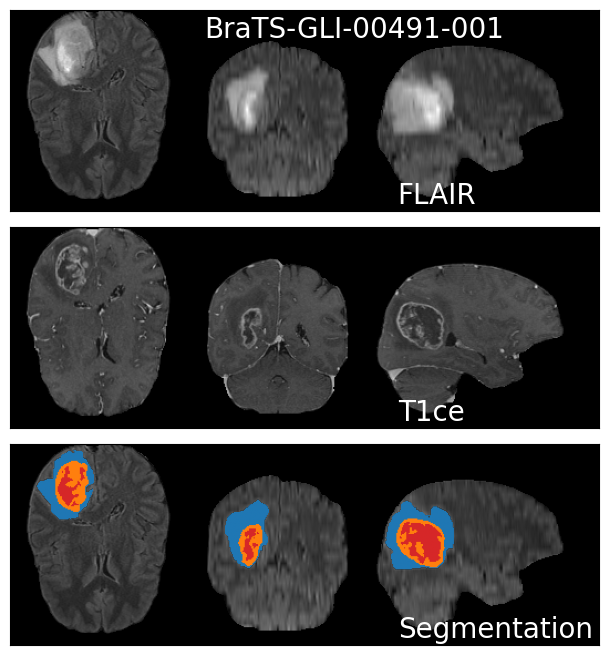

In [5]:
# Plot the image.
plot_images_and_segmentation(image_name=pb.brats_list[img_idx], img_flair=img_flair, img_t1ce=img_t1ce, seg_gt=seg_gt, )

## Full segmentation

In [6]:
# Parameters for the algorithm.
normalize = "max"  # preprocess_brain, divide by max or 255
sigma = 1  # preprocess_brain, Gaussian blur
enhance = (False, True)  # preprocess_brain, apply enhancement or not
radius_enhance = 1  # preprocess_brain, radius of enhancement
dilate = True  # preprocess_brain, apply dilation or not on T1ce
radius_dilation = 2  # preprocess_brain and segment_other_components, radius of dilation
whole_threshold = 1  # segment_whole_object, threshold for suggest_t
max_bars = 1  # segment_geometric_object, number of H2 features to consider

In [7]:
# Segmentation.
seg_final = segment_brain(
    img_flair=img_flair,
    img_t1ce=img_t1ce,
    normalize=normalize,
    sigma=sigma,
    enhance=tuple(enhance),
    radius_enhance=radius_enhance,
    dilate=dilate,
    radius_dilation=radius_dilation,
    whole_threshold=whole_threshold,
    max_bars=max_bars,
    verbose=False,
    plot=False,
)

In [8]:
# Compute Dice scores.
get_multiple_dice(seg_final, seg_gt, verbose=True);

Sørensen–Dice coefficients: {1: np.float64(0.864), 2: np.float64(0.927), 3: np.float64(0.874)} - Whole: 0.966


Well labeled pixels 90393, proportion in image 0.9312817448461309
mislabeled pixels: 6670
Badly segmented pixels 5864


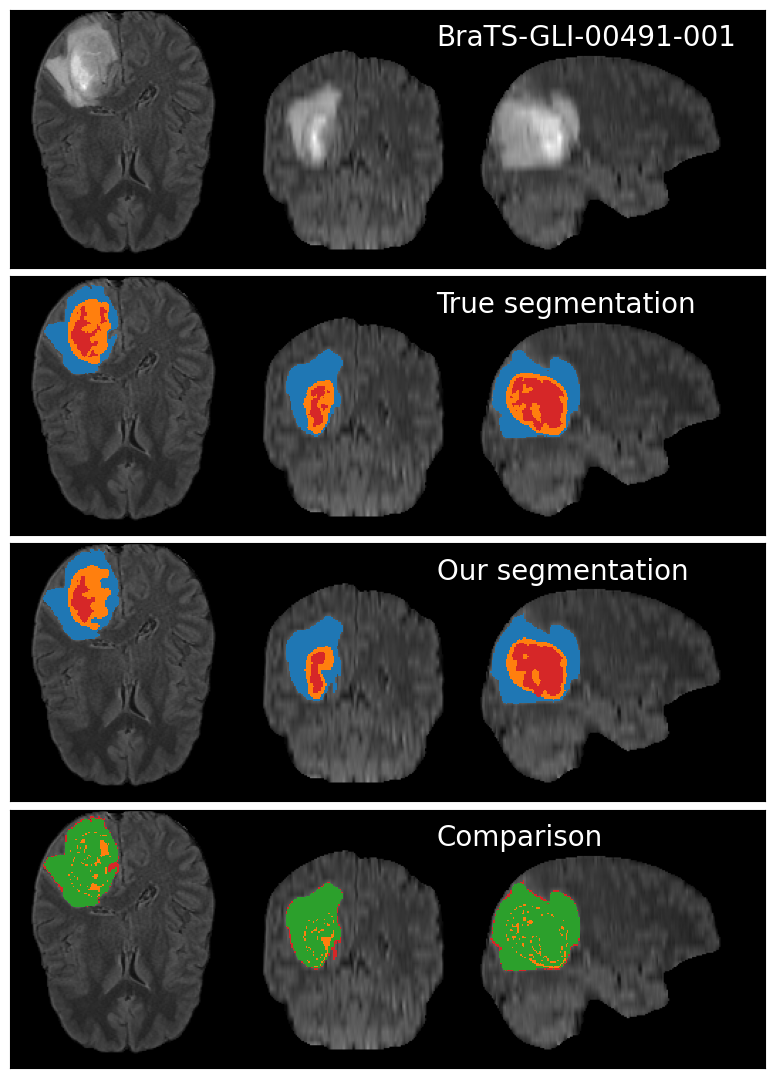

In [9]:
# Compare segmentations.
plot_comparison_full_segmentations(name=pb.brats_list[img_idx],
                                   img=img_flair,
                                   seg_gt=seg_gt,
                                   seg_est=seg_final)

## Segmentation step by step
We now go through the steps of the algorthm, implicitly used in `segmentation_brain()` of the previous cells.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from segmentations import preprocess_brain, segment_whole_object, segment_geometric_object, segment_other_components
from utils import segCmp, plot_comparison_binary_segmentations, plot_segmentation
from morphology import argmax_image

### Preprocessing

In [11]:
# Open a specific image.
img_idx = 4
img_flair, seg_gt = pb(img_idx, to_torch=False, modality="flair", normalize=True)
img_t1ce, _ = pb(img_idx, to_torch=False, modality="t1ce")
print("Image name:", pb.brats_list[img_idx])

Image name: BraTS-GLI-00491-001


In [12]:
# Apply preprocessing.
img_flair, img_t1ce = preprocess_brain(img_flair,
                                       img_t1ce,
                                       sigma=sigma,
                                       normalize=normalize,
                                       enhance=enhance,
                                       dilate=dilate,
                                       radius_dilation=radius_dilation)

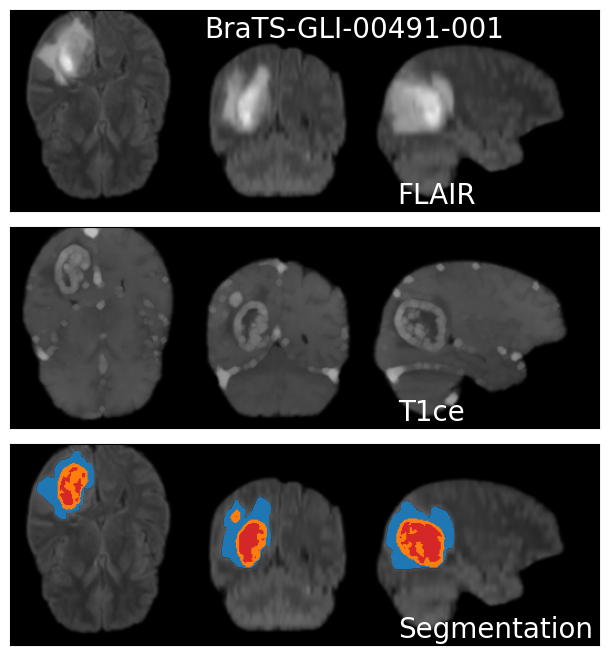

In [13]:
# Plot preprocessed image.
plot_images_and_segmentation(image_name=pb.brats_list[img_idx],
                             img_flair=img_flair,
                             img_t1ce=img_t1ce,
                             seg_gt=seg_gt)

### Step 1 : Union segmentation

In this step, our goal is to select the largest hyper-intense region present in the FLAIR image that we note $X$. To achieve this, we analyse the number of voxels in the filtration process over time, starting from $t=1$ and moving to $t=0$. While the number of voxels increases steadily, we anticipate a sharp increase in the number of voxels when the voxels corresponding to the white and grey matter are included. Therefore, we select the value of $t$ just before this sharp increase. To do this, we examine the derivative of the number of voxels with respect to $t$, and choose the first derivative value that exceeds a predefined threshold. This process is similar to a binarisation algorithm, such as Otsu's method. Once we have selected the optimal value of $t$, we then identify the largest connected component, which corresponds to the region with the most voxels.


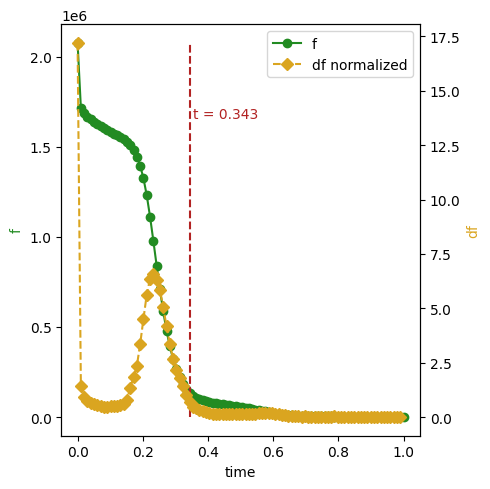

In [14]:
# Segment the whole object.
seg_whole = segment_whole_object(img=img_flair,
                                 threshold=whole_threshold,
                                 verbose=False,
                                 plot=True)

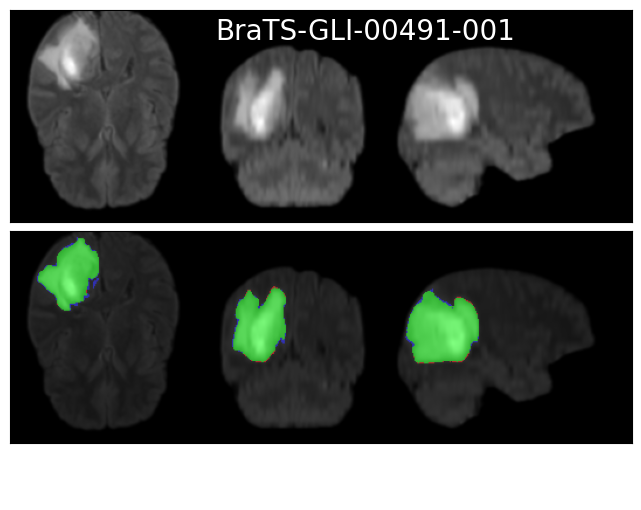

In [15]:
# Plot segmentation of whole object.
seg_binary_gt = (seg_gt > 0) * 1
plot_comparison_binary_segmentations(name=pb.brats_list[img_idx],
                                     img=img_flair,
                                     seg_binary_gt=seg_binary_gt,
                                     seg_binary_est=seg_whole)

### Step 2 : ET Identification

In the previous step, we estimated the global segmentation $X \subset \Omega$, based on the image $I_\mathrm{FLAIR}$.
Note that, according to our model, we can decompose $X$ as $X_\mathrm{ET}\cup X_\mathrm{TC}\cup X_\mathrm{ED}$, although we do not know the components at this point.
In this second step, we will use the image $I_\mathrm{T1ce}$, and the previously estimated segmentation $X$, to obtain $X_\mathrm{ET}$.

According to the model, the enhancing tumour $X_\mathrm{ET}$ is the boundary
of the tumour and is highly intense in the image. Hence, using a superlevel sets filtration, we should see in the $H_2$ persistence diagram a persistent cycle, representing the sphere formed by the boundary of the tumour.
More precisely, we compute the persistent homology of the superlevel sets filtration on the image $I_\mathrm{T1ce}$ restricted to $X$.

In order to automatise this procedure, we follow two steps:
- We compute the persistence diagram of the superlevel sets filtration of the image $I_\mathrm{T1ce}$ restricted to $X$, and identify the $H_2$-point of highest persistence.
- We extract the pixels that form this cycle as follows. Let $t_b$ be the birth value of this persistent cycle, and $x$ the corresponding pixel that gave birth to it. We then define $X_\mathrm{ET}$ as the connected component of the pixel $x$ in the binary image $I_\mathrm{T1ce}^{t_b}$.




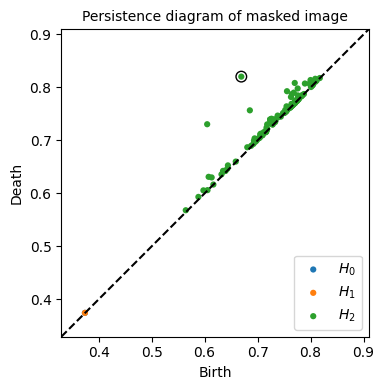

In [16]:
# Segment the geometric object.
seg_geom = segment_geometric_object(img=img_t1ce,
                                    seg_whole=seg_whole,
                                    max_bars=max_bars,
                                    verbose=False,
                                    plot=True)

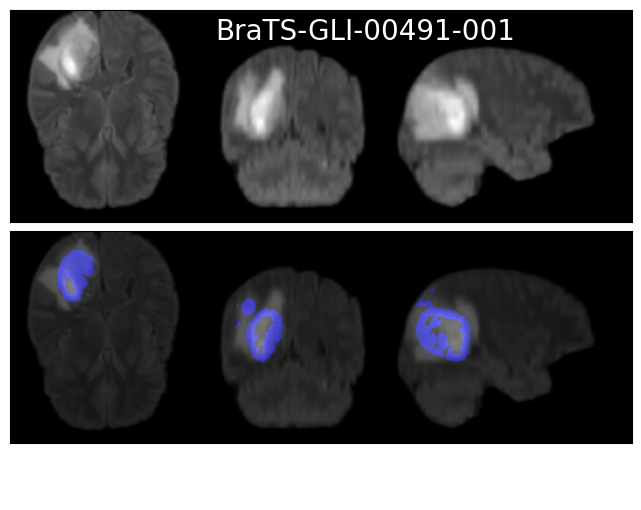

In [17]:
# Plot segmentation of geometric object.
seg_binary_gt = np.zeros(seg_gt.shape)
seg_binary_gt[seg_gt == 4] = 1
plot_comparison_binary_segmentations(name=pb.brats_list[img_idx],
                                     img=img_flair,
                                     seg_binary_gt=seg_binary_gt,
                                     seg_binary_est=seg_geom)

### Step 3: identification of TC and WT

At this point, we have estimated the segmentation of the global tumour, $X$, and the en-
hancing tumour $X_{\mathrm{ET}}$ . We now identify the components $X_{\mathrm{TC}}$ and $X_{\mathrm{WT}}$ . This step does not
depends on the initial MRI, but only on the subsets $X$ and $X_{\mathrm{ET}}$ .

Following our model, $\mathrm{TC}$ corresponds to the part of the tumour that lies inside $\mathrm{ET}$, and
$\mathrm{WT}$ to the part that lies outside $\mathrm{ET}$ (and still within $X$). In order to identify these parts,
we apply the following procedure.


Note the segmentation color code:
- 1. TC (Tumorous Core) in red
- 2. ED (Edema) in blue
- 3. ET (Enhancing Tumor) in orange

In [18]:
# Identify the various components of the segmentation.
seg_final = segment_other_components(seg_whole=seg_whole,
                                     seg_geom=seg_geom,
                                     radius_dilation=radius_dilation,
                                     verbose=True, )

Get connected components... Execution time: 0 s.


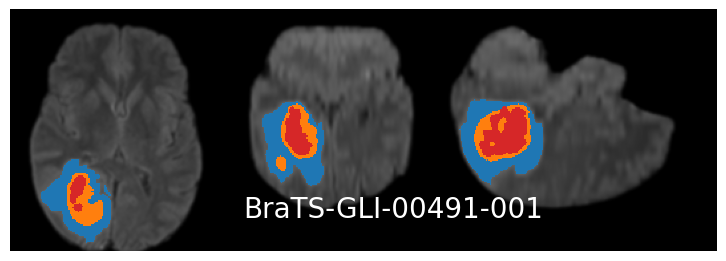

In [19]:
# Plot the final segmentation.
plot_segmentation(name=pb.brats_list[img_idx],
                  img=img_flair,
                  seg=seg_final)

### Compare with the ground-truth segmentation

In [20]:
# Compute scores.
get_multiple_dice(seg_final, seg_gt, verbose=True);

Sørensen–Dice coefficients: {1: np.float64(0.864), 2: np.float64(0.927), 3: np.float64(0.874)} - Whole: 0.966


Well labeled pixels 90393, proportion in image 0.9312817448461309
mislabeled pixels: 6670
Badly segmented pixels 5864


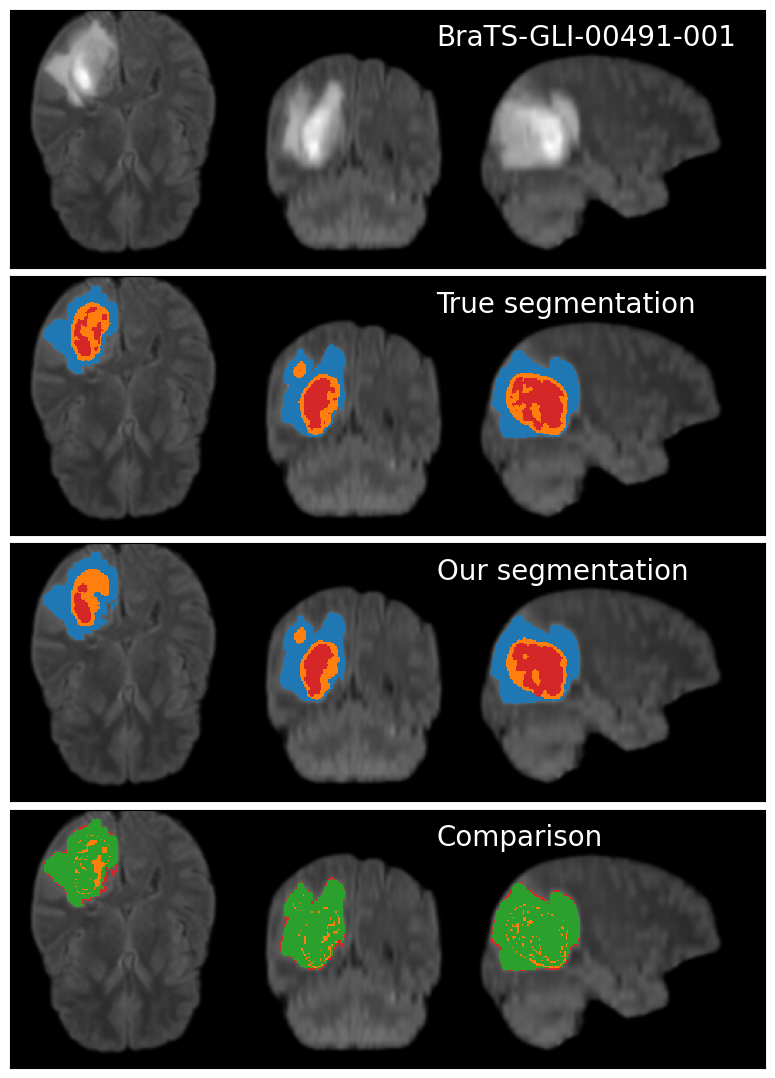

In [21]:
# Compare segmentations.
plot_comparison_full_segmentations(name=pb.brats_list[img_idx], img=img_flair, seg_gt=seg_gt, seg_est=seg_final)

(np.float64(-0.5), np.float64(217.5), np.float64(-0.5), np.float64(181.5))

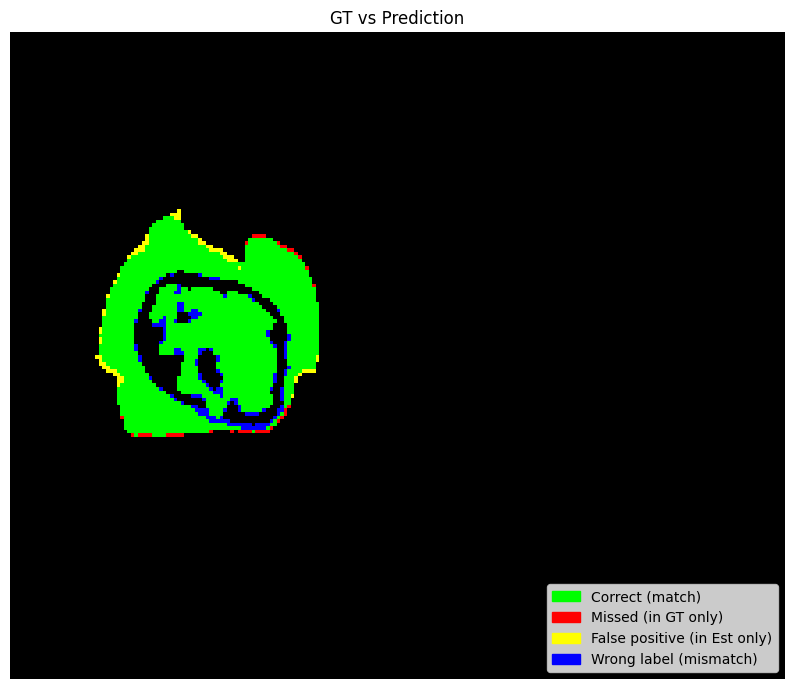

In [22]:
# Compare segmentations in one slice.
pos = argmax_image(img_flair)
gt_slice = seg_gt[pos[0], :, :]
est_slice = seg_final[pos[0], :, :]

cmp_seg, legend_patches = segCmp(gt_slice, est_slice, [1, 2, 4], [1, 2, 4])

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(cmp_seg.transpose((1, 0, 2)), origin='lower')
ax.legend(handles=legend_patches, loc='lower right', frameon=True)
ax.set_title(f"GT vs Prediction")
ax.axis('off')
